In [14]:
from torchvision.models import resnet18, ResNet18_Weights
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from torch.amp import autocast, GradScaler
from torchvision import transforms
import torch.optim as optim
import torch.nn as nn
from PIL import Image
import mediapipe as mp
import numpy as np
import torch
import os
import cv2

In [15]:
data_dir = r"C:\Users\aarik\OneDrive\Dokumen\Projects\gender_classifier\UTKFace"
batch_size = 32
num_epochs = 15
lr = 1e-4

file_paths = []
labels = []

In [16]:
for file_name in os.listdir(data_dir):
    if file_name.endswith(".jpg") or file_name.endswith(".jpg.chip"):
        parts = file_name.split("_")
        if len(parts) >= 2:
            gender = int(parts[1])  
            file_paths.append(os.path.join(data_dir, file_name))
            labels.append(gender)

train_files, val_files, train_labels, val_labels = train_test_split(
    file_paths, labels, test_size=0.2, random_state=42
)

In [17]:
class GenderDataset(Dataset):
    def __init__(self, file_paths, labels, transform=None):
        self.file_paths = file_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        img = Image.open(self.file_paths[idx]).convert("RGB")
        label = self.labels[idx]
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(label, dtype=torch.float32)

In [18]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),  
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.1, scale=(0.02, 0.33), ratio=(0.3, 3.3))
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [19]:
train_dataset = GenderDataset(train_files, train_labels, transform=train_transform)
val_dataset = GenderDataset(val_files, val_labels, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

In [8]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

weights = ResNet18_Weights.IMAGENET1K_V1
model = resnet18(weights=weights)
num_features = model.fc.in_features

model.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(num_features, 256),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(256, 1)
)

model = model.to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=lr)
scaler = GradScaler(device='cuda')
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=3)

In [9]:
save_path = r"C:\Users\aarik\OneDrive\Dokumen\Projects\gender_classifier\model\gender_classifier_torch.pt"

patience = 5  # Early stopping patience
epochs_no_improve = 0

In [10]:
best_val_acc = 0.0

for epoch in range(num_epochs):
    # Training
    model.train()
    running_corrects = 0
    running_total = 0

    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.to(device).unsqueeze(1) 

        optimizer.zero_grad()
        with autocast(device_type=device.type):
            outputs = model(inputs)
            loss = criterion(outputs, labels.float())

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        preds = (torch.sigmoid(outputs) > 0.5).float()
        running_corrects += torch.sum(preds == labels).item()
        running_total += labels.size(0)

    train_acc = running_corrects / running_total

    # Validation
    model.eval()
    val_corrects = 0
    val_total = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device)
            labels = labels.to(device).unsqueeze(1)

            outputs = model(inputs)
            preds = (torch.sigmoid(outputs) > 0.5).float()

            val_corrects += torch.sum(preds == labels).item()
            val_total += labels.size(0)

    val_acc = val_corrects / val_total

    scheduler.step(val_acc)

    print(f"\nEpoch {epoch}/{num_epochs}")
    print(f"Train Accuracy: {train_acc:.4f}")
    print(f"Validation Accuracy: {val_acc:.4f}")

    # Save best model weights
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model, save_path)
        print(f"Saved best model with val_acc: {val_acc:.4f} at {save_path}")
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        print(f"No improvement for {epochs_no_improve} epoch(s)")

    # Early stopping
    if epochs_no_improve >= patience:
        print("\nEarly stopping triggered.")
        break


Epoch 0/15
Train Accuracy: 0.8604
Validation Accuracy: 0.9114
Saved best model with val_acc: 0.9114 at C:\Users\aarik\OneDrive\Dokumen\Projects\gender_classifier\model\gender_classifier_torch.pt

Epoch 1/15
Train Accuracy: 0.9042
Validation Accuracy: 0.9224
Saved best model with val_acc: 0.9224 at C:\Users\aarik\OneDrive\Dokumen\Projects\gender_classifier\model\gender_classifier_torch.pt

Epoch 2/15
Train Accuracy: 0.9162
Validation Accuracy: 0.9306
Saved best model with val_acc: 0.9306 at C:\Users\aarik\OneDrive\Dokumen\Projects\gender_classifier\model\gender_classifier_torch.pt

Epoch 3/15
Train Accuracy: 0.9224
Validation Accuracy: 0.9323
Saved best model with val_acc: 0.9323 at C:\Users\aarik\OneDrive\Dokumen\Projects\gender_classifier\model\gender_classifier_torch.pt

Epoch 4/15
Train Accuracy: 0.9279
Validation Accuracy: 0.9315
No improvement for 1 epoch(s)

Epoch 5/15
Train Accuracy: 0.9323
Validation Accuracy: 0.9270
No improvement for 2 epoch(s)

Epoch 6/15
Train Accuracy: 0.

              precision    recall  f1-score   support

        Male       0.94      0.95      0.94      2485
      Female       0.94      0.93      0.94      2257

    accuracy                           0.94      4742
   macro avg       0.94      0.94      0.94      4742
weighted avg       0.94      0.94      0.94      4742



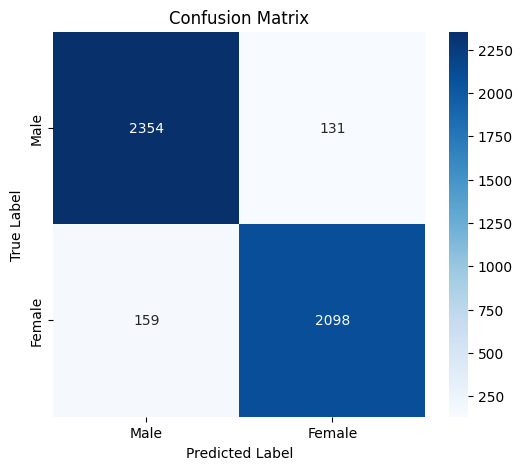

In [12]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

all_labels = []
all_preds = []

model.eval()
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        labels = labels.to(device).unsqueeze(1)  # for BCEWithLogitsLoss output shape

        outputs = model(inputs)
        preds = (torch.sigmoid(outputs) > 0.5).int()

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

all_labels = np.array(all_labels).flatten()
all_preds = np.array(all_preds).flatten()

print(classification_report(all_labels, all_preds, target_names=["Male", "Female"]))

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Male", "Female"],
            yticklabels=["Male", "Female"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [12]:

model_path = r"C:\Users\aarik\OneDrive\Dokumen\Projects\gender_classifier\model\gender_classifier_torch.pt"
model = torch.load(model_path, weights_only=False)
model.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

input_shape = (224, 224)
threshold = 0.5
gender_dict = {0: "Male", 1: "Female"}

transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize(input_shape),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

mp_face_detection = mp.solutions.face_detection
mp_drawing = mp.solutions.drawing_utils

face_detection = mp_face_detection.FaceDetection(model_selection=0, min_detection_confidence=0.5)

cap = cv2.VideoCapture(r"C:\Users\aarik\OneDrive\Dokumen\Projects\gender_classifier\video_gender_dataset\videos\female\TXokRjBVSaA.mp4") 

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    results = face_detection.process(rgb_frame)

    if results.detections:
        for detection in results.detections:
            bbox = detection.location_data.relative_bounding_box
            h, w, _ = frame.shape
            x, y, bw, bh = int(bbox.xmin * w), int(bbox.ymin * h), int(bbox.width * w), int(bbox.height * h)

            if x >= 0 and y >= 0 and bw > 0 and bh > 0:
                face = frame[y:y+bh, x:x+bw]

                if face.size != 0:
                    face_tensor = transform(face).unsqueeze(0).to(device)

                    with torch.no_grad():
                        output = model(face_tensor)
                        prob = torch.sigmoid(output).item()

                    label = gender_dict[int(prob > threshold)]
                    confidence = prob if prob > threshold else 1 - prob

                    color = (0, 255, 0) if label == "Male" else (255, 0, 255)
                    cv2.rectangle(frame, (x, y), (x + bw, y + bh), color, 2)
                    cv2.putText(frame, f"{label} ({confidence*100:.1f}%)", (x, y - 10),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

    cv2.imshow("Gender Classification", frame)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()